# Image Classifier with PyTorch

In [ ]:
# Importing Libaries
import torch
import torchvision
import torchvision.transforms as transforms

In [ ]:
# Loading Dataset and DataLoaders
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

from torch.utils.data import DataLoader
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4
)

100%|██████████| 170M/170M [00:05<00:00, 33.1MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
# Convolutional Layer
import torch.nn as nn

class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()
    self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
    self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
    self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
    self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    self.ReLU = nn.ReLU()
    self.fc1 = nn.Linear(1024, 512)       # i.e 256 * 2 * 2 = 1024
    self.fc2 = nn.Linear(512, 10)
    self.dropout = nn.Dropout(p=0.5)

  def forward(self, x):
    x = self.pool(self.ReLU(self.conv1(x)))   # i.e conv1 → relu → pool
    x = self.pool(self.ReLU(self.conv2(x)))
    x = self.pool(self.ReLU(self.conv3(x)))
    x = self.pool(self.ReLU(self.conv4(x)))
    x = x.view(x.size(0), -1)                       #Flatten
    x = self.dropout(x)
    x = self.ReLU(self.fc1(x))
    x = self.dropout(x)
    x = (self.fc2(x))
    return x

In [ ]:
# Intiate the model
model = CNN()
print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (ReLU): ReLU()
  (fc1): Linear(in_features=1024, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [ ]:
#Features
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
# Training
num_epochs = 20

for epoch in range(num_epochs):
  model.train()
  running_loss = 0.0

  for images, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()

  print(f'Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}')

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1, Loss: 1.9143
Epoch 2, Loss: 1.6107
Epoch 3, Loss: 1.4812
Epoch 4, Loss: 1.3868
Epoch 5, Loss: 1.3217
Epoch 6, Loss: 1.2675
Epoch 7, Loss: 1.2137
Epoch 8, Loss: 1.1670
Epoch 9, Loss: 1.1273
Epoch 10, Loss: 1.0877
Epoch 11, Loss: 1.0533
Epoch 12, Loss: 1.0242
Epoch 13, Loss: 0.9909
Epoch 14, Loss: 0.9666
Epoch 15, Loss: 0.9382
Epoch 16, Loss: 0.9101
Epoch 17, Loss: 0.8920
Epoch 18, Loss: 0.8615
Epoch 19, Loss: 0.8415
Epoch 20, Loss: 0.8196


In [ ]:
# Validation
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy: {100 * correct / total:.2f}%')

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Accuracy: 70.42%


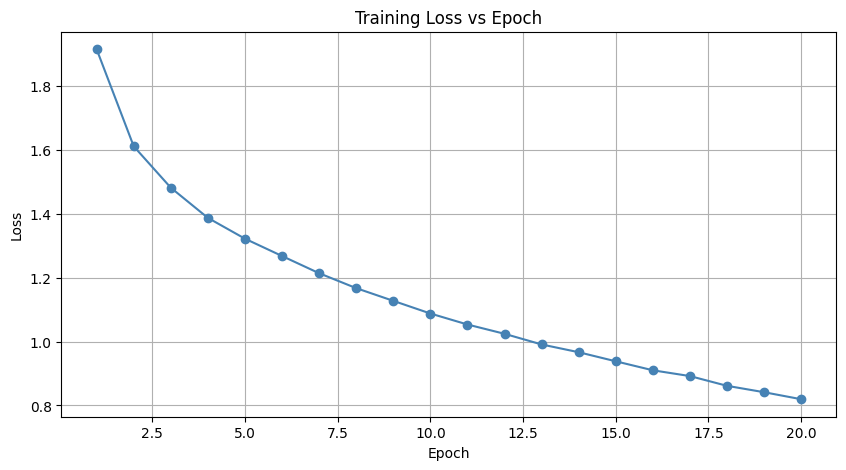

In [ ]:
# Plotting Accuracies
import matplotlib.pyplot as plt

train_losses = [1.9143, 1.6107, 1.4812, 1.3868, 1.3217, 1.2675,
                1.2137, 1.1670, 1.1273, 1.0877, 1.0533, 1.0242,
                0.9909, 0.9666, 0.9382, 0.9101, 0.8920, 0.8615,
                0.8415, 0.8196]

plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), train_losses, marker='o', color='steelblue')
plt.title('Training Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.savefig('training_loss.png', dpi=150)
plt.show()

That is a textbook learning curve smooth, consistent descent from 1.91 down to 0.82. No spikes, no plateaus, no divergence. This is exactly what a healthy training run looks like.